# Exhaustive Generation of Attack Trees for a simple ratchet protocol instance.

This notebook uses Python APIs (no CLI wrappers) of the generator of attack trees to demonstrate the efficiency of exhaustive generation of attack graphs using our second tool

In [37]:
def f(TARGET_QUERY_TAG,filename):
    import sys
    
    from pathlib import Path
    import pandas as pd
    from IPython.display import Markdown, SVG, display
    
    PROJECT_ROOT = Path.cwd().parent
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    
    for module_name in list(sys.modules):
        if module_name == "compareverif" or module_name.startswith("compareverif."):
            del sys.modules[module_name]
    
    EXAMPLES = [
        PROJECT_ROOT / "examples" / "simple_ratchet.pv",
    ]
    
    #TARGET_QUERY_TAG = "secrecy of ma1"
    import os
    import sys
    from contextlib import redirect_stdout, redirect_stderr
    from pathlib import Path
    from compareverif.scenarios import ScenarioPreprocessor
    
    # Blocage de toutes les sorties (print) en les redirigeant vers os.devnull ("nulle part")
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            
            # --- Début de votre code original ---
            
            # Generate full scenario combinations so pinned multi-capability scenarios exist.
            pre = ScenarioPreprocessor(timeout=300)
    
            all_generated = []
            file_to_generated = {}
            file_to_generated_by_name = {}
    
            # Assurez-vous que EXAMPLES est défini avant ce bloc
            for input_file in EXAMPLES:
                input_key = str(input_file)
                generated, out_dir = pre.preprocess(input_key)
                file_to_generated[input_key] = generated
                file_to_generated_by_name[input_key] = {
                    scenario.path.name: scenario for scenario in generated
                }
                all_generated.extend(generated)
    
            results = pre.run_proverif(all_generated)
            analysis = pre.analyze(results, [str(p) for p in EXAMPLES])
    
            # Build compact table focused on the no pw leakage query
            rows = []
            for input_file, by_query in analysis.items():
                model = Path(input_file).stem
                # Assurez-vous que TARGET_QUERY_TAG est défini avant ce bloc
                combos = by_query.get(TARGET_QUERY_TAG, [])
                for combo in combos:
                    caps = sorted(combo["scenarios"])
    
                    cost_items = sorted(combo["costs"].items())
                    rows.append({
                        "model": model,
                        "query": TARGET_QUERY_TAG,
                        "minimal_combo": " + ".join(caps) if caps else "base",
                        "costs": ", ".join(f"{k}:{v}" for k, v in cost_items) if cost_items else "none",
                    })
            
            # Les lignes d'affichage finales ont été complètement supprimées
    
    
    from compareverif.attack_tree import AttackTreeExtractor
    atk = AttackTreeExtractor(timeout=300)
    
    # Render the pinned scenarios for the no pw leakage query using capability-enhanced trees.
    PINNED_SCENARIOS = {
        str(EXAMPLES[0]): filename
    }   
    
    for input_file in map(str, EXAMPLES):
        scenario = file_to_generated_by_name[input_file][PINNED_SCENARIOS[input_file]]
        model = Path(input_file).stem
        combo_scenarios = sorted(capability.name for capability in scenario.capabilities)
    
        #display(Markdown(f"### {model} — {scenario.path.name}"))
        #display(Markdown(f"- Minimal combo: `{', '.join(combo_scenarios) or 'base'}`  \n- Costs: `{scenario.costs}`"))
        #display(Markdown(f"- Scenario capabilities: `{', '.join(combo_scenarios) or 'base'}`"))
    
        build = atk.extract_tree(
            scenario.path,
            query_tag=TARGET_QUERY_TAG,
            scenario_queries=scenario.queries,
            capability_scenarios=file_to_generated[input_file],
            readable_nodes=True,
            show_clause_ids=False,
        )
        if build.tree is None:
            raise RuntimeError("Could not build capability-enhanced tree.")
    
        capability_node_count = sum(
            1 for node in build.tree.nodes.values() if node.node_type == "capability"
        )
        if capability_node_count == 0:
            print("No capability-specific clauses could be attributed inside this derivation tree.")
        else:
            print(f"Capability nodes shown: {capability_node_count}")
    
        dot = build.tree.to_graphviz()
        try:
            import graphviz
            src = graphviz.Source(dot, format="svg")
            svg = src.pipe(format="svg").decode("utf-8")
            display(SVG(svg))
        except Exception:
            # Inline SVG rendering unavailable. Showing DOT snippet:"
            print("\n".join(dot.splitlines()[:20]))

Capability nodes shown: 1


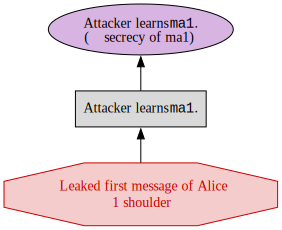

Capability nodes shown: 1


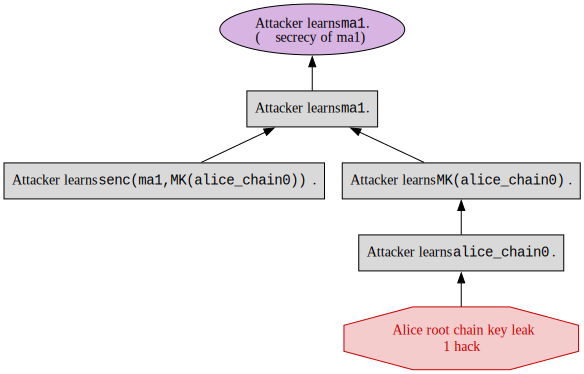

Capability nodes shown: 2


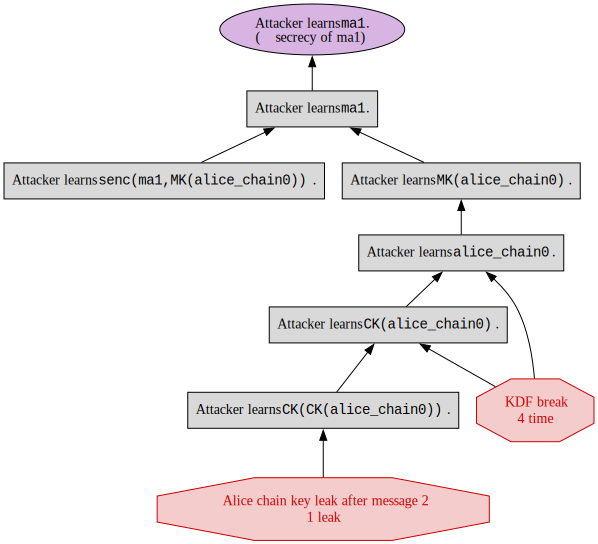

In [39]:
TARGET_QUERY_TAG = "secrecy of ma1"
filename="leaked_first_message_of_alice.pv"
f(TARGET_QUERY_TAG,filename)

TARGET_QUERY_TAG = "secrecy of ma1"
filename="alice_root_chain_key_leak.pv"
f(TARGET_QUERY_TAG,filename)


TARGET_QUERY_TAG = "secrecy of ma1"
filename="kdf_break+alice_chain_key_leak_after_message_2.pv"
f(TARGET_QUERY_TAG,filename)

Capability nodes shown: 1


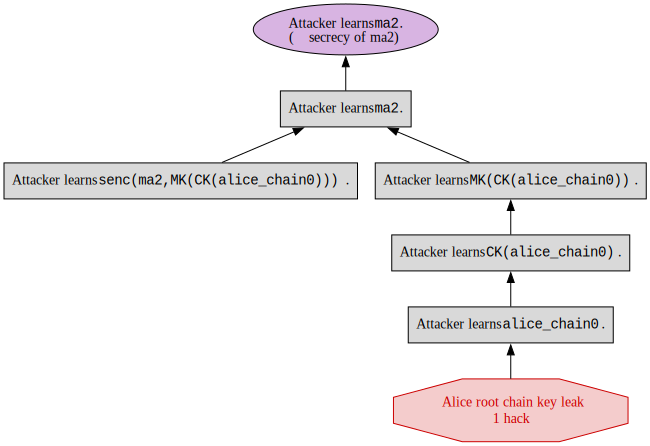

Capability nodes shown: 2


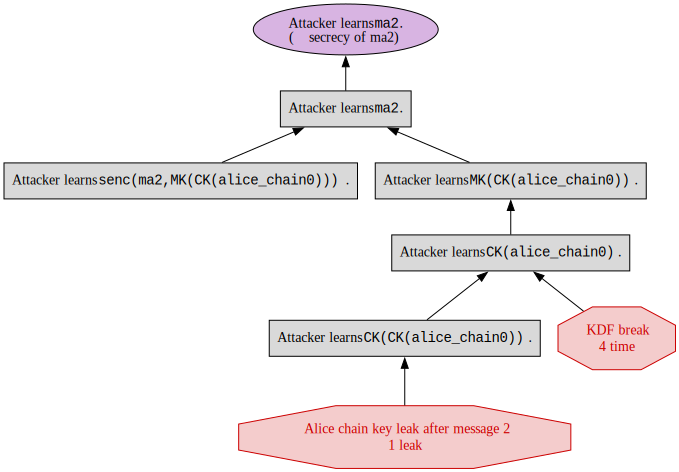

In [40]:
TARGET_QUERY_TAG = "secrecy of ma2"
filename="alice_root_chain_key_leak.pv"
f(TARGET_QUERY_TAG,filename)


TARGET_QUERY_TAG = "secrecy of ma2"
filename="kdf_break+alice_chain_key_leak_after_message_2.pv"
f(TARGET_QUERY_TAG,filename)

Capability nodes shown: 1


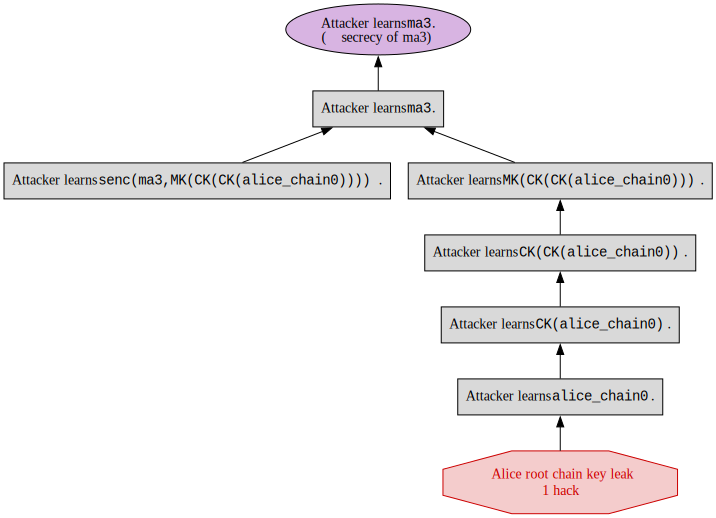

Capability nodes shown: 1


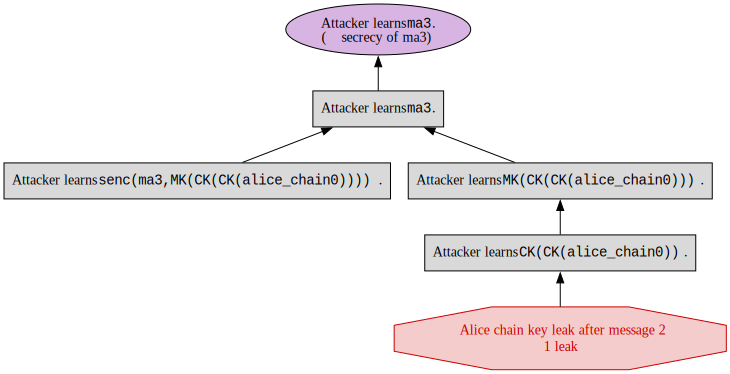

In [41]:
TARGET_QUERY_TAG = "secrecy of ma3"
filename="alice_root_chain_key_leak.pv"
f(TARGET_QUERY_TAG,filename)


TARGET_QUERY_TAG = "secrecy of ma3"
filename="alice_chain_key_leak_after_message_2.pv"
f(TARGET_QUERY_TAG,filename)

Capability nodes shown: 1


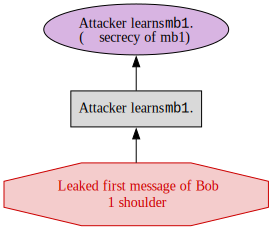

RuntimeError: Could not build capability-enhanced tree.

In [43]:
TARGET_QUERY_TAG = "secrecy of mb1"
filename="leaked_first_message_of_bob.pv"
f(TARGET_QUERY_TAG,filename)


TARGET_QUERY_TAG = "secrecy of mb1"
filename="kdf_break+alice_chain_key_leak_after_message_2.pv"
f(TARGET_QUERY_TAG,filename)

In [23]:
TARGET_QUERY_TAG = "secrecy of mb2"
f(TARGET_QUERY_TAG)

### simple_ratchet — kdf_break+alice_chain_key_leak_after_message_2.pv

- Minimal combo: `Alice chain key leak after message 2, KDF break`  
- Costs: `{'time': 4, 'leak': 1}`

- Scenario capabilities: `Alice chain key leak after message 2, KDF break`

RuntimeError: Could not build capability-enhanced tree.